## 1. Setup

### 1.1 Importar Libs

In [3]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
import json
import pickle
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from scipy.stats import uniform, randint
from joblib import dump, load
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Importar funções dos módulos customizados
from ml_utils import evaluate_model, load_and_prepare_datasets, SCORING_METRIC
from search_utils import (plot_search_history, multiple_randomized_search,
                          plot_search_history_from_loaded, 
                          load_search_results, get_best_params_from_saved,
                          save_search_results, save_final_results, 
                          DEFAULT_CV_STRATEGY, SEARCHES_FOLDER, RESULTS_FOLDER, MODELS_FOLDER)
from manual_implement_models import HeterogeneousStackingCommittee

# Configurações de plotagem
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style("whitegrid")

print("Bibliotecas importadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgb.__version__}")

Bibliotecas importadas com sucesso!
Pandas: 2.3.3
NumPy: 2.2.6
Scikit-learn: 1.7.2
XGBoost: 3.1.2


### 1.2 Configuração do Modelo

In [4]:
# Configuração do modelo e hiperparâmetros
MODEL_NAME = "Stacking"
MODEL_CLASS = HeterogeneousStackingCommittee
RANDOM_STATE_MODEL = 42
RANDOM_STATE_SAMPLE = 10

# Configuração da busca de hiperparâmetros
N_SEARCHES = 20
N_ITER_PER_SEARCH = 10
SAMPLE_SIZE = 0.05  # % of training data for hyperparameter search

print(f"Modelo configurado: {MODEL_NAME}")
print(f"Buscas: {N_SEARCHES} x {N_ITER_PER_SEARCH} iterações")

Modelo configurado: Stacking
Buscas: 20 x 10 iterações


## 2. Carregamento e Preparação dos Dados

In [9]:
# Carregamento e preparação inicial dos dados
print("=== CARREGAMENTO DOS DATASETS ===")

# Carregar e preparar datasets usando função do módulo
X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, train_data, test_data, scaler = load_and_prepare_datasets()

print(f"Dataset de treino: {train_data.shape}")
print(f"Dataset de teste: {test_data.shape}")
print(f"Features: {X_train_scaled.shape[1]}")

print("\nDistribuição das classes:")
print("Treino:", y_train.value_counts().to_dict())
print("Teste:", y_test.value_counts().to_dict())

print("\nPrimeiras linhas do dataset de treino:")

=== CARREGAMENTO DOS DATASETS ===
Dataset de treino: (37233, 1825)
Dataset de teste: (12411, 1825)
Features: 1824

Distribuição das classes:
Treino: {1: 7050, 2: 5577, 3: 4282, 4: 3733, 5: 3430, 7: 2895, 6: 2857, 8: 2537, 0: 2533, 9: 2339}
Teste: {1: 2430, 2: 1790, 3: 1408, 4: 1257, 5: 1203, 6: 995, 7: 912, 8: 815, 0: 813, 9: 788}

Primeiras linhas do dataset de treino:


In [10]:
train_data.head()

,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,BUN,WBC,Platelets,Gender,Unit1,Unit2,HospAdmTime,ICULOS,Critical_Risk_Window,Time_Category,SepsisLabel
0,8,-1.109794,-0.460180,-0.936182,2.873365,3.044201,2.159974,-0.073601,-0.277186,-1.393580,0.450716,1.0,1.0,0.0,-12.06,9.0,0,0,0.0
1,47,0.569971,-2.437770,0.173477,0.393960,0.650783,0.430943,-0.997324,0.309171,0.245616,-0.275108,1.0,1.0,0.0,-0.05,48.0,0,1,0.0
2,6,0.150030,0.978068,0.016114,-0.983487,-0.553850,-0.198683,-0.073601,-0.310739,0.121368,-0.191266,1.0,1.0,0.0,-0.02,7.0,0,0,0.0
3,39,-0.269912,0.258944,0.289355,0.853109,0.405094,-0.115460,0.752015,0.298591,-0.003965,-3.152920,0.0,0.0,1.0,-75.85,43.0,0,1,0.0
4,127,0.569971,-0.460180,0.007012,0.761279,1.834255,1.055050,-0.520987,0.702140,-0.180545,0.030433,0.0,0.0,1.0,-0.03,128.0,1,2,0.0


## 3. Sampling para Busca de Hiperparâmetros

In [ ]:
# ======================================================================
# SAMPLING ESTRATIFICADO PARA BUSCA DE HIPERPARÂMETROS
# ======================================================================

print("=== PREPARAÇÃO DE AMOSTRA PARA BUSCA DE HIPERPARÂMETROS ===")

# Amostra estratificada do dataset de treino
_, X_sample, _, y_sample = train_test_split(
    X_train_scaled, y_train, 
    test_size=SAMPLE_SIZE,  
    stratify=y_train,
    random_state=RANDOM_STATE_SAMPLE
)

print(f"Dataset original de treino: {X_train_scaled.shape[0]:,} amostras")
print(f"Amostra para busca de hiperparâmetros: {X_sample.shape[0]:,} amostras")
print(f"Redução: {(1 - X_sample.shape[0]/X_train_scaled.shape[0])*100:.1f}%")

print("\nDistribuição das classes na amostra:")
print("Amostra:", pd.Series(y_sample).value_counts().to_dict())
print("Original:", y_train.value_counts().to_dict())

=== PREPARAÇÃO DE AMOSTRA PARA BUSCA DE HIPERPARÂMETROS ===
Dataset original de treino: 853,006 amostras
Amostra para busca de hiperparâmetros: 8,531 amostras
Redução: 99.0%

Distribuição das classes na amostra:
Amostra: {0.0: 8312, 1.0: 219}
Original: {0.0: 831112, 1.0: 21894}
Dataset original de treino: 853,006 amostras
Amostra para busca de hiperparâmetros: 8,531 amostras
Redução: 99.0%

Distribuição das classes na amostra:
Amostra: {0.0: 8312, 1.0: 219}
Original: {0.0: 831112, 1.0: 21894}


## 4. Definir Estratégia de Validação Cruzada

In [ ]:
# Usar estratégia de CV padrão dos módulos
print(f"Estratégia de CV: {DEFAULT_CV_STRATEGY}")

## 5. Stacking - Busca de Hiperparâmetros


### 5.1 Definir Espaço de Hiperparâmetros


In [ ]:
# ======================================================================
# DEFINIÇÃO DO ESPAÇO DE HIPERPARÂMETROS - WEAK LEARNERS
# ======================================================================

print(f"=== DEFININDO ESPAÇO DE HIPERPARÂMETROS - {MODEL_NAME} ===")

# Definição do Espaço de Hiperparâmetros para Weak Learners
# Cada range é uma VERSÃO MENOR do espaço original do modelo individual

param_distributions = {
    # === DECISION TREE - Weak (comparar com notebook 3) ===
    # Original: max_depth(3-50), min_samples_split(2-40), min_samples_leaf(1-50)
    'dt_max_depth': randint(1, 5),              # Weak: 1-4 (vs 3-50)
    'dt_min_samples_split': randint(10, 30),    # Weak: 10-29 (vs 2-40)
    'dt_min_samples_leaf': randint(15, 50),     # Weak: 15-49 (vs 1-50)
    
    # === MLP - Weak (comparar com notebook 8) ===
    # Original: 8 arquiteturas (até 4 camadas), alpha(0.01-0.1), LR(0.001-0.1), iter(200-600)
    'mlp_hidden_layers': [(30,), (50,), (100,), (150,), (200,), # Weak: 1-2 camadas (vs até 4)
                          (50, 25), (100, 50), (100, 100), (100,),
                          (50, 50), (25, 200), (25, 25), (50, 200),
                          (150, 50), (100, 150), (150, 25)], 
    'mlp_alpha': uniform(0.05, 0.15),             # Weak: 0.05-0.20 (vs 0.01-0.1)
    'mlp_learning_rate_init': uniform(0.001, 0.05), # Weak: 0.001-0.051 (vs 0.001-0.1)
    'mlp_max_iter': [50, 100, 150],               # Weak: 50-150 (vs 200-600)
    'mlp_activation': ['relu', 'tanh'],           # Subset de ['relu', 'tanh', 'logistic']
    
    # === XGBOOST - Weak (comparar com notebook 6) ===
    # Original: n_est(140-381), depth(3-11), LR(0.5-1.5), subsample(0.6-0.9), reg(0.5-1.5)
    'xgb_n_estimators': randint(20, 60),        # Weak: 20-59 (vs 140-381)
    'xgb_max_depth': randint(1, 4),             # Weak: 1-3 (vs 3-11)
    'xgb_learning_rate': uniform(0.01, 0.15),   # Weak: 0.01-0.16 (vs 0.5-1.5)
    'xgb_subsample': uniform(0.3, 0.3),         # Weak: 0.3-0.6 (vs 0.6-0.9)
    'xgb_colsample_bytree': uniform(0.3, 0.3),  # Weak: 0.3-0.6 (vs 0.2-0.7)
    'xgb_min_child_weight': randint(5, 15),     # Weak: 5-14 (vs 1-20) 
    'xgb_gamma': uniform(0.1, 0.3),             # Weak: 0.1-0.4 (vs 0.1-0.5)
    'xgb_reg_alpha': uniform(0.5, 0.5),         # Weak: 0.5-1.0 (vs 0.5-2.0) 
    'xgb_reg_lambda': uniform(0.5, 0.5),        # Weak: 0.5-1.0 (vs 0.5-2.0)
    
    # === META-ESTIMADOR ===
    'meta_C': uniform(0.1, 10),                 # LogisticRegression
    'meta_max_iter': [1000, 2000, 3000],
}

### 5.2 Executar Busca de Hiperparâmetros

In [ ]:
# ======================================================================
# BUSCA DE HIPERPARAMETROS
# ======================================================================

print(f"=== BUSCA DE HIPERPARÂMETROS - {MODEL_NAME} ===")
print(f"Iniciando busca de hiperparâmetros para {MODEL_NAME}...")
print(f"Executando {N_SEARCHES} buscas com {N_ITER_PER_SEARCH} iterações cada...")
print(f"Usando amostra de {X_sample.shape[0]:,} exemplos\n")

# Múltiplas execuções do RandomizedSearchCV
search, all_searches, best_params = multiple_randomized_search(
    estimator=MODEL_CLASS(random_state=RANDOM_STATE_MODEL, cv=3),
    param_distributions=param_distributions,
    X=X_sample,
    y=y_sample,
    cv_strategy=DEFAULT_CV_STRATEGY,
    n_searches=N_SEARCHES,
    n_iter_per_search=N_ITER_PER_SEARCH,
    scoring=SCORING_METRIC,
    n_jobs=1
)

# Exibir os melhores resultados
print(f"\n--- RESULTADOS {MODEL_NAME} ---")
print("Melhores hiperparâmetros encontrados:")
for param, value in best_params.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1-Score (CV): {search.best_score_:.4f}")
print(f"Desvio padrão: {search.cv_results_['std_test_score'][search.best_index_]:.4f}")

### 5.3 Visualizar Histórico da Busca

In [ ]:
# Registro de Desempenho - plotar evolução da busca
plot_search_history(all_searches, search, MODEL_NAME)

In [ ]:
# ======================================================================
# ANÁLISE DAS MELHORES CONFIGURAÇÕES ENCONTRADAS
# ======================================================================

print(f"=== MELHORES CONFIGURAÇÕES ENCONTRADAS POR BUSCA - {MODEL_NAME} ===")

# Extrair os melhores resultados de cada busca
best_configs = []

for i, search_result in enumerate(all_searches):
    config = {
        'Busca': i + 1,
        'F1_Score': search_result['best_score'],
        **search_result['best_params']
    }
    best_configs.append(config)

# Criar DataFrame e exibir top configs
results_df = pd.DataFrame(best_configs)
results_df = results_df.sort_values('F1_Score', ascending=False).round(4)

print(f"\nTop configurações (de {len(results_df)} buscas):")
print(results_df.to_string(index=False))

print(f"\nEstatísticas dos F1-Scores encontrados:")
print(f"  Média: {results_df['F1_Score'].mean():.4f}")
print(f"  Mediana: {results_df['F1_Score'].median():.4f}")
print(f"  Desvio padrão: {results_df['F1_Score'].std():.4f}")
print(f"  Min: {results_df['F1_Score'].min():.4f}")
print(f"  Max: {results_df['F1_Score'].max():.4f}")

## 6. Salvar Resultados de Busca

In [ ]:

search_df = save_search_results(
    model_name=MODEL_NAME,
    model_search=search,
    model_all_searches=all_searches,
    n_searches=N_SEARCHES,
    n_iter_per_search=N_ITER_PER_SEARCH,
    scoring=SCORING_METRIC,
    cv_folds=DEFAULT_CV_STRATEGY.get_n_splits(),
    top_params_columns=param_distributions.keys(),
    searches_folder=SEARCHES_FOLDER
)

### 6.2 Carregar Resultado de Busca (Opcional)

In [ ]:
loaded_results = load_search_results(MODEL_NAME)

In [ ]:
# Plotar a história da busca a partir dos resultados carregados
plot_search_history_from_loaded(loaded_results, MODEL_NAME)

### 6.3 Definir Melhores Params e CV score

In [ ]:
# Definir Melhores Parâmetros para Uso Posterior
if 'loaded_results' in locals():
    best_params = get_best_params_from_saved(MODEL_NAME)
    # best_score = loaded_results['summary']['best_overall_score']
    print(f"✅ Usando parâmetros carregados: {best_params}")
    print(f"✅ Melhor F1-Score carregado: {best_score:.4f}")
else:
    best_params = search.best_params_
    best_score = search.best_score_
    print(f"✅ Usando parâmetros da busca atual: {best_params}")
    print(f"✅ Melhor F1-Score da busca atual: {best_score:.4f}")

## 7. Treinar Modelo Final e Salvar

In [10]:
# Treinamento Final com melhores hiperparâmetros
    # "decision_tree_max_depth": 3,
    # "decision_tree_min_samples_leaf": 43,
    # "decision_tree_min_samples_split": 24,
    # "mlp_hidden_layer_sizes": [
    #   100
    # ],
    # "mlp_alpha": 0.0734,
    # "mlp_learning_rate_init": 0.0059,
    # "mlp_max_iter": 50,
    # "mlp_activation": "relu",
    # "xgboost_n_estimators": 41,
    # "xgboost_max_depth": 3,
    # "xgboost_learning_rate": 0.1002,
    # "xgboost_subsample": 0.3169,
    # "xgboost_colsample_bytree": 0.5599,
    # "meta_learner_C": 7.3467,
    # "meta_learner_max_iter": 1000
best_model = MODEL_CLASS(dt_max_depth=3, dt_min_samples_leaf=43, dt_min_samples_split=24,
                         mlp_hidden_layers=(100,), mlp_alpha=0.0734, mlp_learning_rate_init=0.0059,
                         mlp_max_iter=50, mlp_activation='relu',
                         xgb_n_estimators=41, xgb_max_depth=3, xgb_learning_rate=0.1002,
                         xgb_subsample=0.3169, xgb_colsample_bytree=0.5599,
                         meta_C=7.3467, meta_max_iter=1000,
                         random_state=RANDOM_STATE_MODEL)
best_model.fit(X_train_scaled, y_train)
print(f"\nModelo final {MODEL_NAME} treinado com dataset completo: {best_model}")


Modelo final Stacking treinado com dataset completo: HeterogeneousStackingCommittee(dt_min_samples_leaf=43, dt_min_samples_split=24,
                               meta_C=7.3467, mlp_alpha=0.0734,
                               mlp_hidden_layers=(100,),
                               mlp_learning_rate_init=0.0059, mlp_max_iter=50,
                               random_state=42, xgb_colsample_bytree=0.5599,
                               xgb_learning_rate=0.1002, xgb_max_depth=3,
                               xgb_n_estimators=41, xgb_subsample=0.3169)


In [11]:

# Save the trained model immediately after training
os.makedirs(MODELS_FOLDER, exist_ok=True)

model_path = os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.joblib')
dump(best_model, model_path)
print(f"✅ Model saved to: {model_path}")

✅ Model saved to: models\stacking_model.joblib


## 8. Avaliação Final e Salvamento dos Resultados

In [ ]:
# Carregar modelo (Opcional)
loaded_model = load(os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.joblib'))

In [12]:
print(f"=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - {MODEL_NAME} ===")

# Criar pastas se não existirem
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Avaliação completa do modelo
print("\nAvaliando performance do modelo...")

# Usar datasets completos para avaliação final
X_train_eval = X_train_scaled
y_train_eval = y_train
X_test_eval = X_test_scaled
y_test_eval = y_test

# Avaliar modelo usando função do módulo
train_metrics, test_metrics, y_test_pred = evaluate_model(
    best_model, X_train_eval, X_test_eval, y_train_eval, y_test_eval, MODEL_NAME
)

=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - Stacking ===

Avaliando performance do modelo...


### 8.1 Classification Report

In [13]:
print(classification_report(y_test_eval, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       813
           1       0.86      0.90      0.88      2430
           2       0.87      0.88      0.87      1790
           3       0.80      0.79      0.79      1408
           4       0.85      0.84      0.85      1257
           5       0.81      0.83      0.82      1203
           6       0.80      0.76      0.78       995
           7       0.87      0.84      0.85       912
           8       0.77      0.73      0.74       815
           9       0.79      0.76      0.77       788

    accuracy                           0.83     12411
   macro avg       0.82      0.82      0.82     12411
weighted avg       0.83      0.83      0.83     12411



### 8.2 Visualize Confusion Matrix

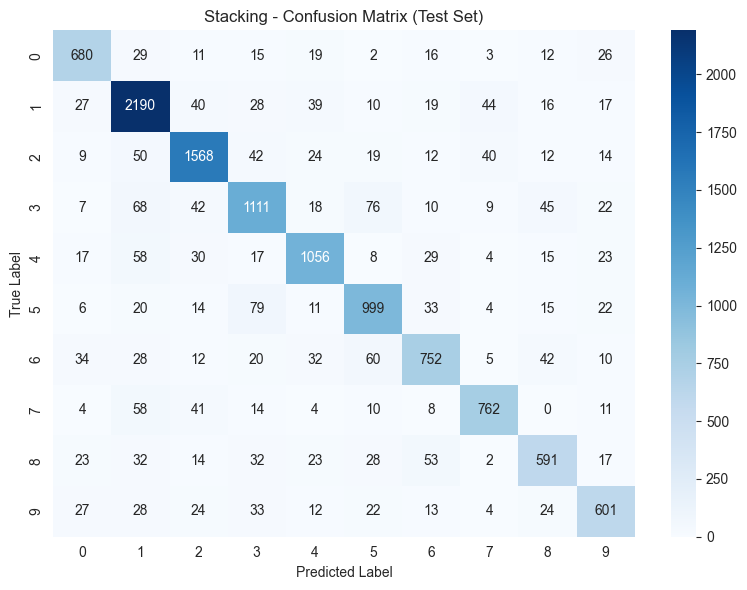

In [14]:
# Plot confusion matrix
cm = confusion_matrix(y_test_eval, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{MODEL_NAME} - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 8.3 Save Final Results

In [18]:
# Salvar resultados finais usando função do módulo
best_score = 0.5011
model_final_results = save_final_results(
    model_name=MODEL_NAME,
    best_params=best_params,
    best_score=best_score,
    train_metrics=train_metrics,
    test_metrics=test_metrics,
    y_pred=y_test_pred,
    y_test=y_test_eval,
    X_train_scaled=X_train_eval,
    X_test_scaled=X_test_eval,
    results_folder=RESULTS_FOLDER
)

# Mostrar resumo final
print(f"\n--- RESUMO FINAL {MODEL_NAME} ---")
print(f"F1-Score CV: {model_final_results['best_cv_score']:.4f}")
print(f"F1-Score Teste: {test_metrics['f1']:.4f}")
print(f"Acurácia Teste: {test_metrics['accuracy']:.4f}")
print(f"Precisão Teste: {test_metrics['precision']:.4f}")
print(f"Recall Teste: {test_metrics['recall']:.4f}")
print(f"G-Mean Teste: {test_metrics['gmean']:.4f}")

print(f"Resultados salvos em: {RESULTS_FOLDER}/")
print(f"\nAvaliação do {MODEL_NAME} concluída com sucesso!")

✅ Resultados Stacking salvos em: results\stacking_results.json

--- RESUMO FINAL Stacking ---
F1-Score CV: 0.5011
F1-Score Teste: 0.8185
Acurácia Teste: 0.8307
Precisão Teste: 0.8223
Recall Teste: 0.8152
G-Mean Teste: 0.8135
Resultados salvos em: results/

Avaliação do Stacking concluída com sucesso!
